# Model bulding and selection

# Choosing a model

In [ ]:
%pip install numpy pandas scikit-learn statsmodels seaborn matplotlib ipympl

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

from app import ingest_data


In [2]:
df = ingest_data.process("cs-train")
df.head()

,year,month,country,revenue,times_viewed,date
0,2017,11,Australia,40.40,97.0,2017-11-01
1,2017,11,Belgium,130.00,1.0,2017-11-01
2,2017,11,Denmark,2.10,15.0,2017-11-01
3,2017,11,EIRE,570.21,737.0,2017-11-01
4,2017,11,France,352.42,704.0,2017-11-01


In [3]:
# Split into training and testing periods
unique_dates = df['date'].drop_duplicates()
total_periods = len(unique_dates)
train_periods = int(total_periods * 0.8)
test_periods = total_periods - train_periods
print(f"Training periods: {train_periods}, Testing periods: {test_periods}")

# Prepare data with lagged features and encode categorical variables
# Create one-month lagged revenue feature
df['prev_month_revenue'] = df.groupby('country')['revenue'].shift(1)

# Convert country names to numerical labels
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['country_id'] = encoder.fit_transform(df['country'])

# Perform time-based train-test split
df = df.sort_values(by='date')
all_dates = df['date'].unique()
train_split = all_dates[:train_periods]
test_split = all_dates[train_periods:train_periods + test_periods]
train_data = df[df['date'].isin(train_split)]
test_data = df[df['date'].isin(test_split)]

# Display dataset information
print("Training Data Dimensions:", train_data.shape)
print("Testing Data Dimensions:", test_data.shape)
print("Training Dates:", train_data['date'].min(), "to", train_data['date'].max())
print("Testing Dates:", test_data['date'].min(), "to", test_data['date'].max())

# Identify top 10 countries by revenue
top_countries = train_data.groupby('country')['revenue'].sum().nlargest(10).index
print("\nTop 10 Countries by Revenue:", list(top_countries))

Training periods: 13, Testing periods: 4
Training Data Dimensions: (297, 8)
Testing Data Dimensions: (99, 8)
Training Dates: 2017-11-01 00:00:00 to 2019-03-01 00:00:00
Testing Dates: 2019-04-01 00:00:00 to 2019-07-01 00:00:00

Top 10 Countries by Revenue: ['United Kingdom', 'EIRE', 'Norway', 'Germany', 'France', 'Hong Kong', 'Netherlands', 'Belgium', 'Sweden', 'Switzerland']


## Baseline Model

baseline model using last known value:

In [4]:

baseline_results = test_data[['date', 'country', 'revenue']].copy()
baseline_results['forecasted_revenue'] = np.nan

# Retrieve last revenue value per country from training data
final_train_values = train_data.groupby('country').tail(1)[['country', 'revenue']].set_index('country')
for country in baseline_results['country'].unique():
    if country in final_train_values.index:
        baseline_results.loc[baseline_results['country'] == country, 'forecasted_revenue'] = final_train_values.loc[country, 'revenue']
    else:
        print(f"Missing training data for {country}, defaulting to 0.")
        baseline_results.loc[baseline_results['country'] == country, 'forecasted_revenue'] = 0

# Aggregate total revenue forecasts
baseline_agg = baseline_results.groupby('date')['forecasted_revenue'].sum()
actual_agg = test_data.groupby('date')['revenue'].sum()

# Show sample baseline forecasts
print("Baseline Forecast Sample:")
print(baseline_results.head(10))

Missing training data for European Community, defaulting to 0.
Baseline Forecast Sample:
          date         country     revenue  forecasted_revenue
315 2019-04-01        Portugal     214.860              334.88
312 2019-04-01           Japan     111.180              112.77
313 2019-04-01     Netherlands      54.930              549.47
314 2019-04-01          Poland      77.590               36.61
316 2019-04-01       Singapore   12309.610              219.75
321 2019-04-01  United Kingdom  130373.041           138856.41
322 2019-04-01     Unspecified      36.500              131.90
318 2019-04-01          Sweden     183.800               92.06
319 2019-04-01     Switzerland     425.010              282.02
320 2019-04-01             USA      74.200              117.33


## ARIMA

In [5]:
arima_results = test_data[['date', 'country', 'revenue']].copy()
arima_results['forecasted_revenue'] = np.nan
country_list = train_data['country'].unique()

# Fit ARIMA model per country
for country in country_list:
    train_subset = train_data[train_data['country'] == country][['date', 'revenue']].set_index('date')
    test_subset = test_data[test_data['country'] == country][['date', 'revenue']].set_index('date')
    
    # Skip countries with insufficient data
    if len(train_subset) < 6:
        print(f"Not enough data for {country}: {len(train_subset)} months available.")
        continue
    
    # Set monthly frequency
    train_subset = train_subset.asfreq('MS').fillna(0)
    
    # Train and predict with ARIMA
    try:
        arima_model = ARIMA(train_subset['revenue'], order=(1,1,1), seasonal_order=(0,0,0,12))
        fitted_model = arima_model.fit()
        if len(test_subset) > 0:
            forecast = fitted_model.forecast(steps=len(test_subset))
            arima_results.loc[(arima_results['country'] == country) & 
                            (arima_results['date'].isin(test_subset.index)), 'forecasted_revenue'] = forecast.values
    except Exception as error:
        print(f"ARIMA error for {country}: {error}")
        continue

# Aggregate ARIMA forecasts
arima_agg = arima_results.groupby('date')['forecasted_revenue'].sum()
arima_actual_agg = test_data.groupby('date')['revenue'].sum()

# Display sample ARIMA forecasts
print("ARIMA Forecast Sample:")
print(arima_results.head(10))

Not enough data for Nigeria: 2 months available.
Not enough data for Bermuda: 1 months available.
Not enough data for Bahrain: 4 months available.
Not enough data for Singapore: 2 months available.
Not enough data for Unspecified: 5 months available.
Not enough data for Hong Kong: 5 months available.
Not enough data for Thailand: 2 months available.
Not enough data for Israel: 4 months available.
Not enough data for Lithuania: 2 months available.
Not enough data for West Indies: 1 months available.
Not enough data for Malta: 1 months available.
Not enough data for Lebanon: 2 months available.
Not enough data for Korea: 3 months available.
Not enough data for Brazil: 1 months available.
Not enough data for RSA: 1 months available.
Not enough data for Canada: 3 months available.
Not enough data for Iceland: 1 months available.
Not enough data for Saudi Arabia: 1 months available.
Not enough data for Czech Republic: 2 months available.
ARIMA Forecast Sample:
          date         country

## Random Forest Regressor

In [6]:
# Cell 5: Train Random Forest model
model_features = ['country_id', 'month', 'year', 'times_viewed', 'prev_month_revenue']
X_train_rf = train_data[model_features].fillna(0)
y_train_rf = train_data['revenue']
X_test_rf = test_data[model_features].fillna(0)
y_test_rf = test_data['revenue']

# Fit Random Forest model
from sklearn.ensemble import RandomForestRegressor
rf_classifier = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_classifier.fit(X_train_rf, y_train_rf)

# Generate predictions
rf_results = test_data[['date', 'country', 'revenue']].copy()
rf_results['forecasted_revenue'] = rf_classifier.predict(X_test_rf)

# Aggregate Random Forest forecasts
rf_agg = rf_results.groupby('date')['forecasted_revenue'].sum()
rf_actual_agg = test_data.groupby('date')['revenue'].sum()

# Display feature importance
importances = pd.Series(rf_classifier.feature_importances_, index=model_features)
print("Random Forest Feature Rankings:")
print(importances.sort_values(ascending=False))

# Show sample Random Forest forecasts
print("\nRandom Forest Forecast Sample:")
print(rf_results.head(10))

Random Forest Feature Rankings:
prev_month_revenue    0.911088
month                 0.075771
times_viewed          0.007833
country_id            0.002770
year                  0.002538
dtype: float64

Random Forest Forecast Sample:
          date         country     revenue  forecasted_revenue
315 2019-04-01        Portugal     214.860          429.141804
312 2019-04-01           Japan     111.180          292.837258
313 2019-04-01     Netherlands      54.930          637.952388
314 2019-04-01          Poland      77.590          116.292536
316 2019-04-01       Singapore   12309.610          331.350569
321 2019-04-01  United Kingdom  130373.041       168607.820500
322 2019-04-01     Unspecified      36.500          527.425545
318 2019-04-01          Sweden     183.800          258.974450
319 2019-04-01     Switzerland     425.010          322.430795
320 2019-04-01             USA      74.200          220.591287


# Evaluation

In [7]:
def evaluate_model(actual, predicted, model_name):
    rmse_score = np.sqrt(mean_squared_error(actual, predicted))
    mae_score = mean_absolute_error(actual, predicted)
    return {'Model': model_name, 'RMSE': rmse_score, 'MAE': mae_score}

# Compute metrics for each model
baseline_clean = baseline_results.dropna()
baseline_scores = evaluate_model(baseline_clean['revenue'], baseline_clean['forecasted_revenue'], 'Baseline')

arima_clean = arima_results.dropna()
arima_scores = evaluate_model(arima_clean['revenue'], arima_clean['forecasted_revenue'], 'ARIMA')

rf_scores = evaluate_model(rf_results['revenue'], rf_results['forecasted_revenue'], 'Random Forest')

# Compute total revenue error
def calculate_total_error(actual, predicted, model_name):
    abs_percentage_error = np.abs(predicted.sum() - actual.sum()) / actual.sum() * 100
    return {'Model': model_name, 'Total Revenue APE (%)': abs_percentage_error}

baseline_total_scores = calculate_total_error(actual_agg, baseline_agg, 'Baseline')
arima_total_scores = calculate_total_error(arima_actual_agg, arima_agg, 'ARIMA')
rf_total_scores = calculate_total_error(rf_actual_agg, rf_agg, 'Random Forest')

# Metrics for top 10 countries
baseline_top10_data = baseline_clean[baseline_clean['country'].isin(top_countries)]
arima_top10_data = arima_clean[arima_clean['country'].isin(top_countries)]
rf_top10_data = rf_results[rf_results['country'].isin(top_countries)]
baseline_top10_scores = evaluate_model(baseline_top10_data['revenue'], baseline_top10_data['forecasted_revenue'], 'Baseline (Top 10)')
arima_top10_scores = evaluate_model(arima_top10_data['revenue'], arima_top10_data['forecasted_revenue'], 'ARIMA (Top 10)')
rf_top10_scores = evaluate_model(rf_top10_data['revenue'], rf_top10_data['forecasted_revenue'], 'Random Forest (Top 10)')

# Combine and display metrics
all_metrics = pd.DataFrame([baseline_scores, arima_scores, rf_scores])
total_metrics = pd.DataFrame([baseline_total_scores, arima_total_scores, rf_total_scores])
top10_metrics = pd.DataFrame([baseline_top10_scores, arima_top10_scores, rf_top10_scores])

print("\nCountry-Level Metrics:")
print(all_metrics)
print("\nTotal Revenue Error Metrics:")
print(total_metrics)
print("\nTop 10 Countries Metrics:")
print(top10_metrics)



Country-Level Metrics:
           Model         RMSE          MAE
0       Baseline  5779.730480  1803.127677
1          ARIMA  8810.879887  2253.641079
2  Random Forest  5000.434691  1771.661904

Total Revenue Error Metrics:
           Model  Total Revenue APE (%)
0       Baseline               9.260115
1          ARIMA              21.406851
2  Random Forest              13.958489

Top 10 Countries Metrics:
                    Model          RMSE          MAE
0       Baseline (Top 10)   9142.975763  3948.443514
1          ARIMA (Top 10)  13201.118378  4711.888985
2  Random Forest (Top 10)   7593.941411  3305.373209


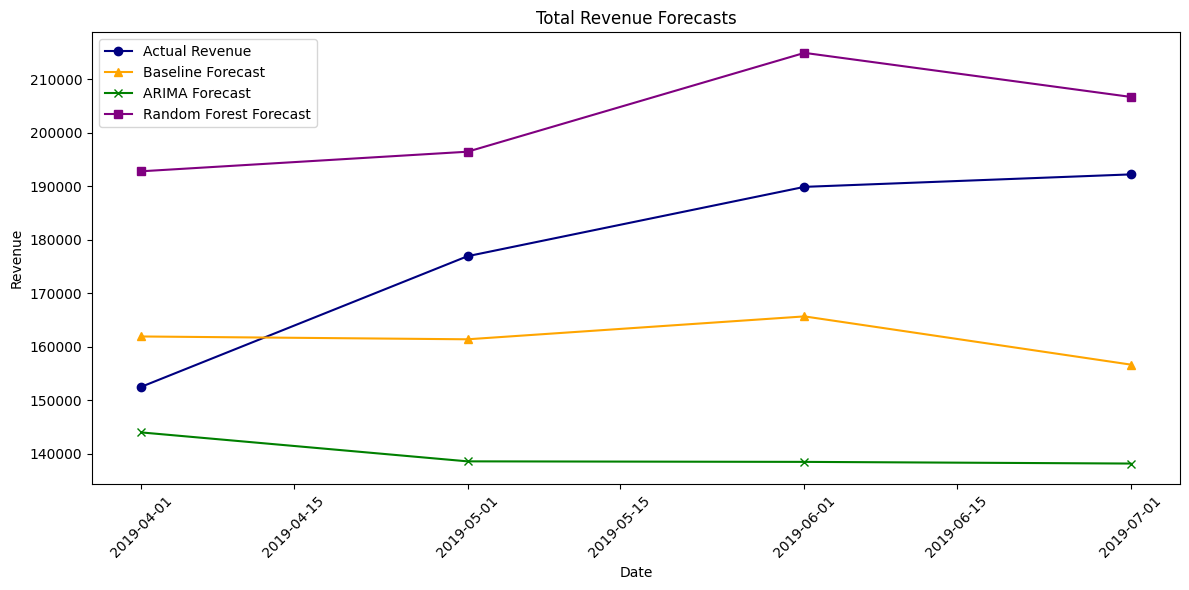

In [8]:
# total revenue forecasts
plt.figure(figsize=(12, 6))
plt.plot(actual_agg.index, actual_agg.values, label='Actual Revenue', marker='o', color='navy')
plt.plot(baseline_agg.index, baseline_agg.values, label='Baseline Forecast', marker='^', color='orange')
plt.plot(arima_agg.index, arima_agg.values, label='ARIMA Forecast', marker='x', color='green')
plt.plot(rf_agg.index, rf_agg.values, label='Random Forest Forecast', marker='s', color='purple')
plt.title("Total Revenue Forecasts")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


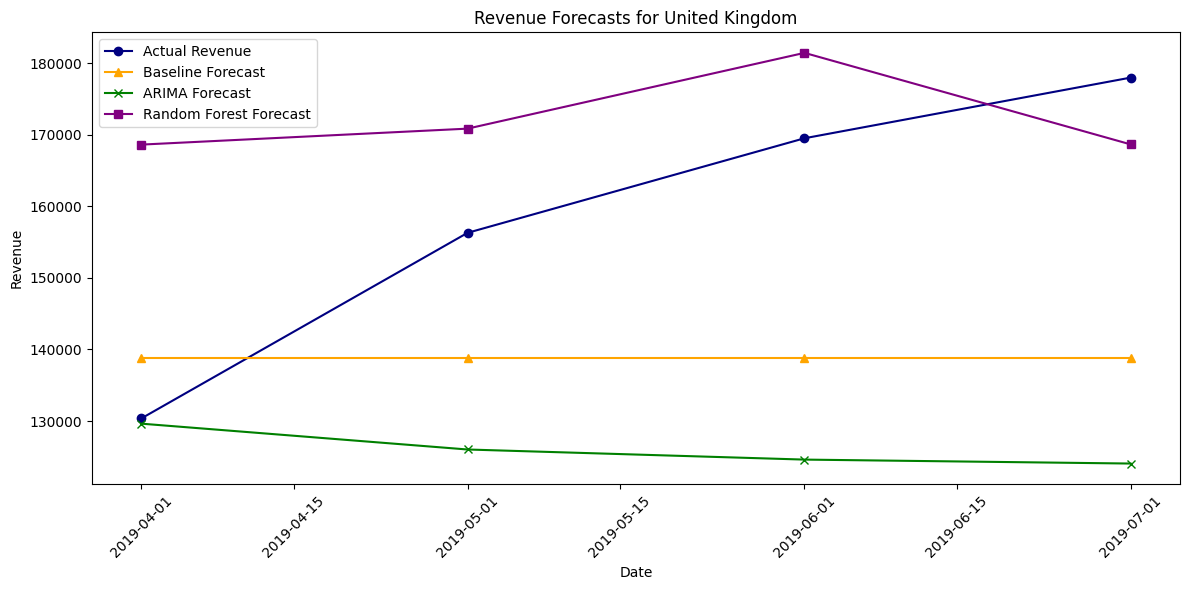

In [9]:
# revenue for top country
top_country = top_countries[0]
baseline_subset = baseline_results[baseline_results['country'] == top_country]
arima_subset = arima_results[arima_results['country'] == top_country]
rf_subset = rf_results[rf_results['country'] == top_country]
actual_subset = test_data[test_data['country'] == top_country]
plt.figure(figsize=(12, 6))
plt.plot(actual_subset['date'], actual_subset['revenue'], label='Actual Revenue', marker='o', color='navy')
plt.plot(baseline_subset['date'], baseline_subset['forecasted_revenue'], label='Baseline Forecast', marker='^', color='orange')
plt.plot(arima_subset['date'], arima_subset['forecasted_revenue'], label='ARIMA Forecast', marker='x', color='green')
plt.plot(rf_subset['date'], rf_subset['forecasted_revenue'], label='Random Forest Forecast', marker='s', color='purple')
plt.title(f"Revenue Forecasts for {top_country}")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

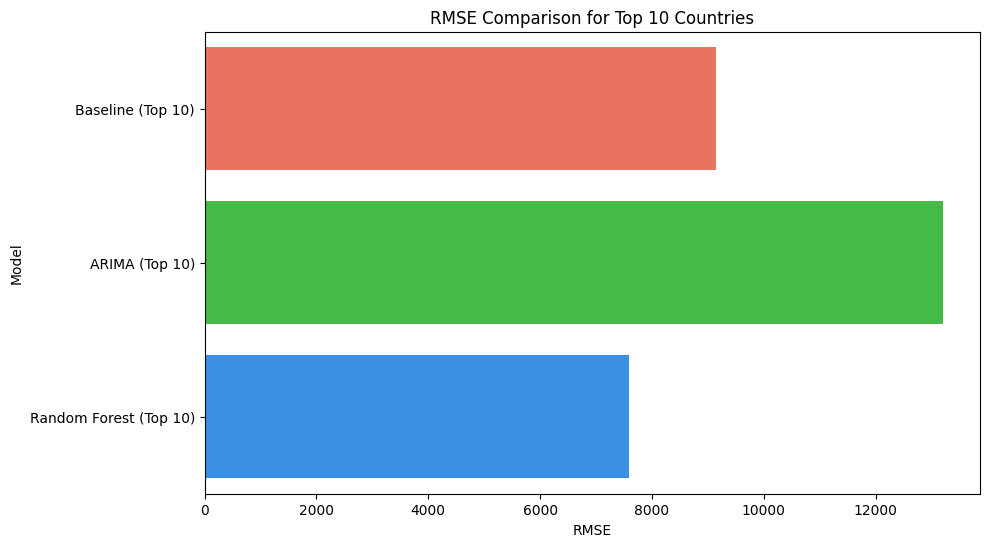

In [10]:
# Bar plot for top 10 countries' RMSE
plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE', y='Model', data=top10_metrics, hue='Model', palette=['#FF6347', '#32CD32', '#1E90FF'])
plt.title("RMSE Comparison for Top 10 Countries")
plt.xlabel("RMSE")
plt.show()

## Model selection

In [11]:
# Cell 9: Identify best model based on RMSE for top 10 countries
top10_rmse = top10_metrics.set_index('Model')['RMSE']
best_performing_model = top10_rmse.idxmin()
best_performing_model

'Random Forest (Top 10)'